# NOAA Global Ocean Heat Content

The heat stored in the upper 700 meters of the world ocean, estimated quarterly by NOAA's National
Centers for Environmental Information from the Levitus objective analysis. The ocean absorbs most of
the energy the climate system retains, so this series moves more smoothly than surface temperature
and is harder to explain away as weather.

## Provenance

These are the fields of the `OCEAN_HEAT` declaration in `climate_risk/data/ocean_heat.py`, which is
what `fetch` reads. Check that file rather than this page if the two ever disagree.

In [1]:
import dataclasses

from IPython.display import Markdown

from climate_risk.data.ocean_heat import OCEAN_HEAT

declared = {"publisher": "NOAA National Centers for Environmental Information"} | dataclasses.asdict(OCEAN_HEAT)

rows = [f"| {field} | {value} |" for field, value in declared.items()]

Markdown("\n".join(["| Field | Value |", "|---|---|", *rows]))

| Field | Value |
|---|---|
| publisher | NOAA National Centers for Environmental Information |
| url | https://www.ncei.noaa.gov/data/oceans/woa/DATA_ANALYSIS/3M_HEAT_CONTENT/DATA/basin/3month/ohc_levitus_climdash_seasonal.csv |
| filename | ohc_levitus_climdash_seasonal.csv |
| license | public domain (U.S. Government work, 17 U.S.C. 105) |
| citation | NOAA National Centers for Environmental Information, global ocean heat content. https://doi.org/10.7289/V53F4MVP |
| retrieved | 2026-08-05 |

## Loading it

The published record is quarterly. The loader averages each calendar year and returns one row per
year, so this frame joins onto the other annual series. The cache directory is your choice, and this
page uses one named `data` in the working directory.

In [2]:
import logging

from pathlib import Path

import matplotlib.pyplot as plt

import climate_risk as cr

from climate_risk.plotting import PALETTE, configure_plot_style

configure_plot_style(add_grid=True)

# The package installs an INFO handler when nothing else has, and a cache hit logs a line.
logging.getLogger("climate_risk").setLevel(logging.WARNING)

In [3]:
cache_dir = Path("data")

ocean_heat = cr.load_ocean_heat_data(cache_dir)

## What you get

A polars frame. Which of polars and pandas a loader returns varies across this package, so it is
worth checking per loader. The column types are in the table header.

In [4]:
ocean_heat.head()

Date,Temp
date,f64
1955-01-01,148.798853
1956-01-01,149.391649
1957-01-01,147.386721
1958-01-01,150.467113
1959-01-01,149.810599


## Units

| Column | Unit |
|---|---|
| `Date` | first day of the year averaged |
| `Temp` | 10^22 joules, shifted by `OCEAN_HEAT_BASELINE_OFFSET` |

NCEI serves the file without a header, so nothing the loader keeps records the unit. This one comes
from the publisher's documentation rather than from anything in the repository.

## Coverage

`describe` answers the span and the spread in one call, computed from the frame you just loaded, so
it cannot go stale when NCEI extends the record.

In [5]:
ocean_heat.describe()

statistic,Date,Temp
str,str,f64
"""count""","""72""",72.0
"""null_count""","""0""",0.0
"""mean""","""1990-07-02 12:00:00""",156.421009
"""std""",null,8.173329
"""min""","""1955-01-01""",146.272496
"""25%""","""1973-01-01""",149.810599
"""50%""","""1991-01-01""",153.088339
"""75%""","""2008-01-01""",162.240431
"""max""","""2026-01-01""",176.225098


## A plot

Annual mean heat content, on the project's shifted baseline.

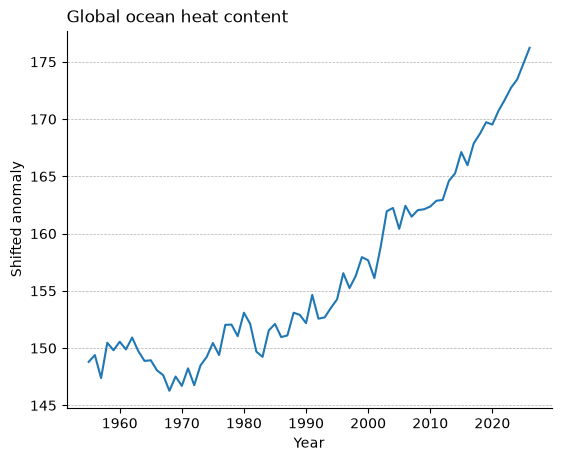

In [6]:
figure, axis = plt.subplots(figsize=(5.5, 4.5))
axis.plot(ocean_heat["Date"], ocean_heat["Temp"], color=PALETTE["primary"])
axis.set_title("Global ocean heat content", loc="left")
axis.set_xlabel("Year")
axis.set_ylabel("Shifted anomaly")

plt.show()

## Gotchas

*`Temp` is not a temperature.* It is ocean heat content, published as an anomaly in units of 10^22
joules. The column takes its name from `new_columns=["Date", "Temp"]` in the loader, and nothing
upstream calls it that.

*The values are not the published anomalies.* `OCEAN_HEAT_BASELINE_OFFSET` adds 152 to every row, to
put the series on the baseline this project's published results were estimated against. The
derivation of 152 is unrecorded, and changing it invalidates every downstream number. Subtract it to
recover what NCEI serves.

*The most recent year is a partial average.* Upstream publishes four seasons a year and the loader
averages whatever has been published, so the current year is the mean of however many quarters exist.
It arrives as a single quarter and drifts as the other three land.

*NCEI serves no header row.* The first line of the CSV is an observation, not column names. Open it
with `has_header=False` or the earliest season is read as a header and lost.

*The month is written unpadded below October.* Dates read `1955-3`, not `1955-03`, so a `%Y-%m` parse
rejects most of the file. The loader splits on the hyphen and keeps the year, which is all the annual
average needs.